Revenue Prediction
==================
In this project the goal is to predict movies revenue using their features. revenue is given by ( box_office - budget ) so the main goal is to predict box office. 

1. Prepare and preprocess the given data. 

2. After exploring data find, select and especially create new features. ignore others.

3. Prepare features to feed the model. 

4. Select and try different models.

5. Document and report each step using relative plots and a brief explanation. finally report the best suited model and justify why did it performed well.



- Keep in mind that in this task accuracy itself only has only part of score.

- Hint: to create new features you can use credit attributes. Think of it this way, what affects box office?  

**Tools** 

importing useful tools and libraries. you may use any other library as well.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Modelling
from sklearn import preprocessing, svm 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Tree Visualisation
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

import ast
import json
from sklearn.preprocessing import LabelEncoder

C:\Users\niush\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
np.random.seed(42)

In [3]:
# Your project struct must look like this,


# |── Name_SID.zip
# │   ├── data
# │   │       ├── rotten_tomatoes_5000_movies.csv
# │   │       ├── rotten_tomatoes_5000_movies.csv
# │   ├── *.ipynb
# │   ├── document.pdf

df_movies = pd.read_csv(r"data/rotten_tomatoes_5000_movies.csv")
df_credit = pd.read_csv(r"data/rotten_tomatoes_5000_credits.csv")


<h1>DataSet Informations</h1>

<h3> Movies Dataset Information </h3>

In [4]:
display(df_movies.head())
df_movies.info()

,rt_production_budget,rt_genres,rt_website,rt_movie_id,rt_keywords,rt_original_language,rt_original_title,rt_synopsis,rt_audience_score,rt_studios,rt_production_countries,rt_release_date,rt_box_office,rt_runtime,rt_languages,rt_release_status,rt_tagline,rt_title,rt_critics_score,rt_review_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   rt_production_budget     4803 non-null   int64  
 1   rt_genres                4803 non-null   object 
 2   rt_website               1712 non-null   object 
 3   rt_movie_id              4803 non-null   int64  
 4   rt_keywords              4803 non-null   object 
 5   rt_original_language     4803 non-null   object 
 6   rt_original_title        4803 non-null   object 
 7   rt_synopsis              4800 non-null   object 
 8   rt_audience_score        4803 non-null   float64
 9   rt_studios               4803 non-null   object 
 10  rt_production_countries  4803 non-null   object 
 11  rt_release_date          4802 non-null   object 
 12  rt_box_office            4803 non-null   int64  
 13  rt_runtime               4801 non-null   float64
 14  rt_languages            

In [5]:
df_movies['rt_box_office'].eq(0).sum()


1427

<h3> Credit Dataset Information </h3>

In [6]:
display(df_credit.head())
df_credit.info()
df_credit.describe()
print("Total null values: ", df_credit.isnull().sum().sum())

,rt_movie_id,rt_title,rt_actors,rt_staff
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   rt_movie_id  4803 non-null   int64 
 1   rt_title     4803 non-null   object
 2   rt_actors    4803 non-null   object
 3   rt_staff     4803 non-null   object
dtypes: int64(1), object(3)
memory usage: 150.2+ KB
Total null values:  0


In [7]:
df_movies_rt = df_movies[df_movies['rt_box_office']!=0]
y = df_movies_rt['rt_box_office']
X = df_movies_rt.drop(columns='rt_box_office')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25) 

In [8]:
df_movies_rt.info()
df_movies_rt.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 3376 entries, 0 to 4798
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   rt_production_budget     3376 non-null   int64  
 1   rt_genres                3376 non-null   object 
 2   rt_website               1396 non-null   object 
 3   rt_movie_id              3376 non-null   int64  
 4   rt_keywords              3376 non-null   object 
 5   rt_original_language     3376 non-null   object 
 6   rt_original_title        3376 non-null   object 
 7   rt_synopsis              3376 non-null   object 
 8   rt_audience_score        3376 non-null   float64
 9   rt_studios               3376 non-null   object 
 10  rt_production_countries  3376 non-null   object 
 11  rt_release_date          3376 non-null   object 
 12  rt_box_office            3376 non-null   int64  
 13  rt_runtime               3376 non-null   float64
 14  rt_languages             3376

,rt_production_budget,rt_movie_id,rt_audience_score,rt_box_office,rt_runtime,rt_critics_score,rt_review_count
count,3.376000e+03,3376.000000,3376.000000,3.376000e+03,3376.000000,3376.000000,3376.000000
mean,3.888424e+07,45518.799171,28.260492,1.170314e+08,110.382109,6.308738,944.422690
std,4.420490e+07,74725.406344,35.622362,1.834831e+08,21.116082,0.882279,1392.846418
min,0.000000e+00,5.000000,0.019984,5.000000e+00,0.000000,0.000000,0.000000
25%,8.500000e+06,5538.250000,9.957286,1.535290e+07,96.000000,5.800000,160.750000
50%,2.500000e+07,11581.500000,19.755221,5.175184e+07,106.000000,6.300000,440.500000
75%,5.200000e+07,47370.750000,36.425937,1.401651e+08,121.000000,6.900000,1091.250000
max,3.800000e+08,417859.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


In [9]:
print("Before Removing 0s of rt_box_office:\n")
print(df_movies.isnull().sum()[df_movies.isnull().sum() > 0])

print("\nNull Percentage:")
null_percent = (df_movies.isnull().sum() / len(df_movies)) * 100
null_percent = null_percent[null_percent > 0]  # فقط ستون‌هایی که مقدار Null دارند

print(null_percent)

print("\nTotal null values: ", df_movies.isnull().sum().sum())

Before Removing 0s of rt_box_office:

rt_website         3091
rt_synopsis           3
rt_release_date       1
rt_runtime            2
rt_tagline          844
dtype: int64

Null Percentage:
rt_website         64.355611
rt_synopsis         0.062461
rt_release_date     0.020820
rt_runtime          0.041641
rt_tagline         17.572351
dtype: float64

Total null values:  3941


In [10]:
print("\nAfter Removing 0s of rt_box_office:")
print(df_movies_rt.isnull().sum()[df_movies_rt.isnull().sum() > 0])
print("Total null values: ", df_movies_rt.isnull().sum().sum())


After Removing 0s of rt_box_office:
rt_website    1980
rt_tagline     282
dtype: int64
Total null values:  2262


<h1>Preprocess</h1>

<h4>Dealing with nulls</h4>

1. Removing an Unnecessary Column ('rt_website')

In [11]:
df_movies.drop(columns=['rt_website'], inplace=True)

2. Filling Missing Values in 'rt_synopsis'

In [12]:
df_movies.fillna({'rt_synopsis': ""}, inplace=True)

3. Removing Rows with Missing 'rt_release_date' and Ensuring Consistency with df_credit

In [13]:
# Drop rows with Null values in 'rt_release_date' from df_movies
df_movies = df_movies.dropna(subset=['rt_release_date'])

# Apply the same deletion to df_credit based on 'rt_movie_id'
df_credit = df_credit[df_credit['rt_movie_id'].isin(df_movies['rt_movie_id'])]

# Print the number of rows in both datasets to ensure consistency
print("Number of rows in df_movies:", len(df_movies))
print("Number of rows in df_credit:", len(df_credit))

Number of rows in df_movies: 4802
Number of rows in df_credit: 4802


4. Filling Missing Values in 'rt_runtime' with the Median

In [14]:
df_movies.loc[:, 'rt_runtime'] = df_movies['rt_runtime'].fillna(df_movies['rt_runtime'].median())

5. Filling Missing Values in 'rt_tagline'

In [15]:
df_movies.loc[:, 'rt_tagline'] = df_movies['rt_tagline'].fillna("")

<h4>Dealing with outliers</h4>

In [16]:
print(df_movies.describe())

       rt_production_budget    rt_movie_id  rt_audience_score  rt_box_office  \
count          4.802000e+03    4802.000000        4802.000000   4.802000e+03   
mean           2.905109e+07   57098.234902          21.496776   8.227777e+07   
std            4.072447e+07   88581.302370          31.818451   1.628697e+08   
min            0.000000e+00       5.000000           0.000372   0.000000e+00   
25%            8.000000e+05    9013.750000           4.671734   0.000000e+00   
50%            1.500000e+07   14626.500000          12.924931   1.917498e+07   
75%            4.000000e+07   58589.750000          28.332017   9.291920e+07   
max            3.800000e+08  459488.000000         875.581305   2.787965e+09   

        rt_runtime  rt_critics_score  rt_review_count  
count  4802.000000       4802.000000      4802.000000  
mean    106.896501          6.093440       690.361724  
std      22.557033          1.191496      1234.674268  
min       0.000000          0.000000         0.000000  

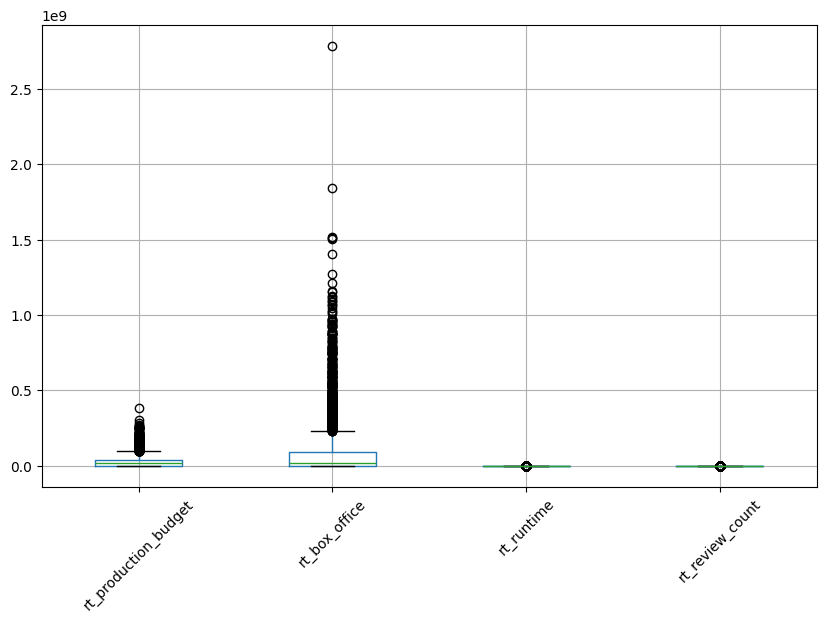

In [17]:
plt.figure(figsize=(10,6))
df_movies[['rt_production_budget', 'rt_box_office', 'rt_runtime', 'rt_review_count']].boxplot()
plt.xticks(rotation=45)
plt.show()

In [18]:
# Define the function to cap outliers based on IQR
def cap_outliers(df_movies, df_credit, column):
    Q1 = df_movies[column].quantile(0.25)
    Q3 = df_movies[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Create a mask to identify rows that will be modified
    mask = (df_movies[column] < lower_bound) | (df_movies[column] > upper_bound)
    
    # Apply the capping on both datasets
    df_movies.loc[mask, column] = df_movies[column].clip(lower_bound, upper_bound)

# Apply the function to budget and box office revenue
cap_outliers(df_movies, df_credit, 'rt_production_budget')
cap_outliers(df_movies, df_credit, 'rt_box_office')


C:\Users\niush\AppData\Local\Temp\ipykernel_12392\1160980274.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[2.32297988e+08 2.32297988e+08 2.32297988e+08 2.32297988e+08
 2.32297988e+08 2.32297988e+08 2.32297988e+08 2.32297988e+08
 2.32297988e+08 2.32297988e+08 2.32297988e+08 2.32297988e+08
 2.32297988e+08 2.32297988e+08 2.32297988e+08 2.32297988e+08
 2.32297988e+08 2.32297988e+08 2.32297988e+08 2.32297988e+08
 2.32297988e+08 2.32297988e+08 2.32297988e+08 2.32297988e+08
 2.32297988e+08 2.32297988e+08 2.32297988e+08 2.32297988e+08
 2.32297988e+08 2.32297988e+08 2.32297988e+08 2.32297988e+08
 2.32297988e+08 2.32297988e+08 2.32297988e+08 2.32297988e+08
 2.32297988e+08 2.32297988e+08 2.32297988e+08 2.32297988e+08
 2.32297988e+08 2.32297988e+08 2.32297988e+08 2.32297988e+08
 2.32297988e+08 2.32297988e+08 2.32297988e+08 2.32297988e+08
 2.32297988e+08 2.32297988e+08 2.32297988e+08 2.32297988e+08
 2.3229798

In [19]:
# Define the function to remove outliers based on IQR
def remove_outliers(df_movies, df_credit, column):
    Q1 = df_movies[column].quantile(0.25)
    Q3 = df_movies[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Create a mask for rows to keep
    mask = (df_movies[column] >= lower_bound) & (df_movies[column] <= upper_bound)

    # Filter both datasets based on this mask
    df_movies_filtered = df_movies[mask]
    df_credit_filtered = df_credit[df_credit['rt_movie_id'].isin(df_movies_filtered['rt_movie_id'])]

    return df_movies_filtered, df_credit_filtered

# Apply the function to runtime and review count
df_movies, df_credit = remove_outliers(df_movies, df_credit, 'rt_runtime')
df_movies, df_credit = remove_outliers(df_movies, df_credit, 'rt_review_count')

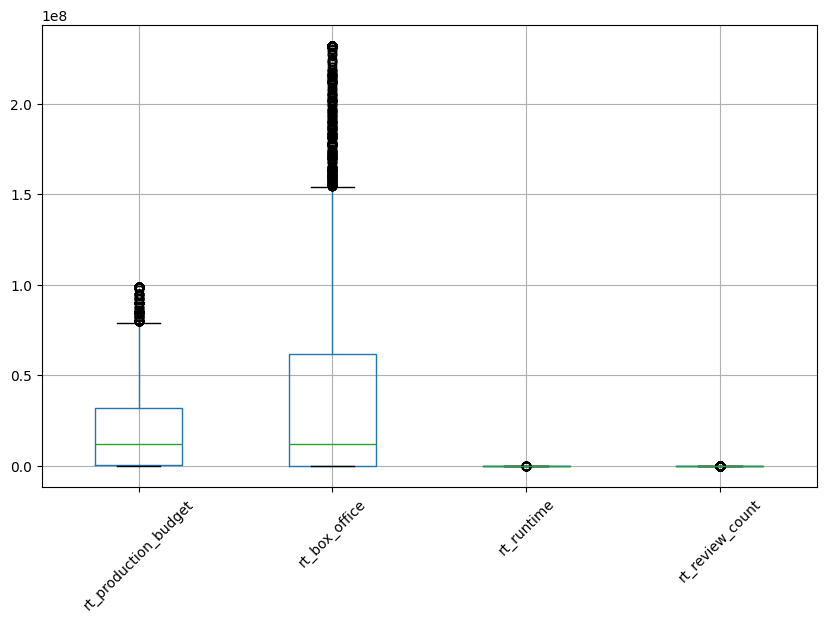

In [20]:
plt.figure(figsize=(10,6))
df_movies[['rt_production_budget', 'rt_box_office', 'rt_runtime', 'rt_review_count']].boxplot()
plt.xticks(rotation=45)
plt.show()

Ensuring Data Consistency: Sorting & Index Reset After Outlier Removal

In [21]:
df_movies.sort_values(by='rt_movie_id', ascending=True, inplace=True)
df_movies.reset_index(drop=True, inplace=True)

df_credit.sort_values(by='rt_movie_id', ascending=True, inplace=True)
df_credit.reset_index(drop=True, inplace=True)

<h4>Encoding & Feature Engineering</h4>

**Encoding text data and categories**

1. Encoding for 'rt_genres' Using Predefined IDs

In [22]:

# Extract all unique genres into a dictionary
all_genres = set()
df_movies['rt_genres'] = df_movies['rt_genres'].apply(ast.literal_eval)  # Convert string to list of dictionaries
for genres in df_movies['rt_genres']:
    for genre in genres:
        all_genres.add((genre['id'], genre['name']))

# Create a mapping dictionary for genre names to their corresponding IDs
genre_dict = {name: gid for gid, name in all_genres}

# Print the final dictionary of genres
print(genre_dict)

# since the IDs had been obvious from before, we used dictionary, and not LabelEncoder

{'Horror': 27, 'Animation': 16, 'Mystery': 9648, 'Action': 28, 'Comedy': 35, 'Romance': 10749, 'Western': 37, 'War': 10752, 'Family': 10751, 'Documentary': 99, 'Drama': 18, 'Foreign': 10769, 'Fantasy': 14, 'Adventure': 12, 'Thriller': 53, 'Crime': 80, 'Music': 10402, 'History': 36, 'Science Fiction': 878, 'TV Movie': 10770}


In [23]:
# Replace genre names with their respective IDs in each movie's genre list
df_movies['rt_genres'] = df_movies['rt_genres'].apply(lambda x: [genre['id'] for genre in x])

# Convert the list of genre IDs into a string format (comma-separated)
df_movies['rt_genres'] = df_movies['rt_genres'].apply(lambda x: ','.join(map(str, x)))  # Store as a numeric string

2. Encoding for 'rt_original_language' Using Label Encoding

In [24]:
# # Extract all unique languages and assign an ID
# unique_languages = df_movies['rt_original_language'].unique()
# language_dict = {lang: idx for idx, lang in enumerate(unique_languages)}

# # Replace language names with their assigned ID
# df_movies['rt_original_language'] = df_movies['rt_original_language'].map(language_dict)

# # Print the mapping dictionary
# print(language_dict)

{'en': 0, 'de': 1, 'zh': 2, 'ja': 3, 'es': 4, 'da': 5, 'it': 6, 'sv': 7, 'hi': 8, 'pt': 9, 'af': 10, 'fr': 11, 'ko': 12, 'ro': 13, 'ru': 14, 'nl': 15, 'ar': 16, 'he': 17, 'th': 18, 'cn': 19, 'tr': 20, 'cs': 21, 'fa': 22, 'no': 23, 'ps': 24, 'vi': 25, 'el': 26, 'hu': 27, 'nb': 28, 'xx': 29, 'id': 30, 'pl': 31, 'is': 32, 'ky': 33, 'sl': 34}


In [24]:
original_language_le = LabelEncoder()
df_movies['rt_original_language'] = original_language_le.fit_transform(df_movies['rt_original_language'])

print(original_language_le.classes_)

['af' 'ar' 'cn' 'cs' 'da' 'de' 'el' 'en' 'es' 'fa' 'fr' 'he' 'hi' 'hu'
 'id' 'is' 'it' 'ja' 'ko' 'ky' 'nb' 'nl' 'no' 'pl' 'ps' 'pt' 'ro' 'ru'
 'sl' 'sv' 'th' 'tr' 'vi' 'xx' 'zh']


3. Encoding for 'rt_production_countries' Using Numeric IDs

In [25]:
# Step 1: Print a few sample values before processing
print("Sample values before conversion:")
print(df_movies['rt_production_countries'].head(10))

# Step 2: Extract unique country names and ISO codes
all_countries = set()
iso_dict = {}  # Dictionary for ISO codes

for country_list in df_movies['rt_production_countries']:
    if isinstance(country_list, str) and country_list.startswith('[') and 'name' in country_list:  
        try:
            country_list = json.loads(country_list)  # Convert JSON string to list of dictionaries
        except (ValueError, json.JSONDecodeError):
            continue  # Skip malformed data

    if not isinstance(country_list, list):  # Ensure it's a valid list
        continue  

    for country in country_list:
        if isinstance(country, dict):  # Ensure each item is a dictionary
            country_name = country.get('name', '').lower().strip()
            iso_code = country.get('iso_3166_1', '').upper().strip()

            if country_name:  # Avoid empty values
                all_countries.add(country_name)
                iso_dict[country_name] = iso_code  # Map country name to ISO code

# Step 3: Assign a unique ID to each country
country_dict = {country: idx for idx, country in enumerate(sorted(all_countries), start=1)}

# Final Debugging: Print the mapping dictionaries
print("\nFinal Country Dictionary (Name to ID):", country_dict)
print("\nFinal ISO Code Dictionary (Name to ISO Code):", iso_dict)

Sample values before conversion:
0    [{"iso_3166_1": "US", "name": "United States o...
1    [{"iso_3166_1": "AR", "name": "Argentina"}, {"...
2            [{"iso_3166_1": "DE", "name": "Germany"}]
3    [{"iso_3166_1": "CA", "name": "Canada"}, {"iso...
4    [{"iso_3166_1": "DE", "name": "Germany"}, {"is...
5    [{"iso_3166_1": "US", "name": "United States o...
6    [{"iso_3166_1": "US", "name": "United States o...
7    [{"iso_3166_1": "US", "name": "United States o...
8    [{"iso_3166_1": "US", "name": "United States o...
9     [{"iso_3166_1": "GB", "name": "United Kingdom"}]
Name: rt_production_countries, dtype: object

Final Country Dictionary (Name to ID): {'afghanistan': 1, 'algeria': 2, 'angola': 3, 'argentina': 4, 'aruba': 5, 'australia': 6, 'austria': 7, 'bahamas': 8, 'belgium': 9, 'bhutan': 10, 'bolivia': 11, 'bosnia and herzegovina': 12, 'brazil': 13, 'bulgaria': 14, 'cambodia': 15, 'cameroon': 16, 'canada': 17, 'chile': 18, 'china': 19, 'colombia': 20, 'cyprus': 21, 'czech re

In [26]:
# Replace country names with their corresponding IDs in the dataset
df_movies['rt_production_countries'] = df_movies['rt_production_countries'].apply(
    lambda x: ','.join([str(country_dict[country['name'].lower().strip()]) for country in x]) 
    if isinstance(x, list) else ""
)

4. Encoding for 'rt_release_status' Using Label Encoding

In [27]:
release_status_le = LabelEncoder()
df_movies['rt_release_status'] = release_status_le.fit_transform(df_movies['rt_release_status'])

print(release_status_le.classes_)

['Post Production' 'Released' 'Rumored']


**Text data processing**

5. Entity Embedding for 'rt_keywords' using Predefined IDs

Attention!!!


Since we are using a list of ids here, we should be aware that this is 'Dictionary Mapping' </br>
It's usable for classic models like 'Random Forest', 'SVM' and so on </br>
But this type of mapping isn't usable for models like 'Neural Networks' and 'Deep Learnings' </br>
If we want to use these models (like Deep Learning), we need to add an Embedding Layer to convert the IDs into meaningful vectors. (Embedding entity)


Also it's noticable that for 'Deep Learning' models, for previous mappings (one to one), it they are Categorical and not Ordinal they need to be converted to Embedded entities.

In [28]:
# Step 1: Extract all unique keywords and their IDs
all_keywords = set()

df_movies['rt_keywords'] = df_movies['rt_keywords'].apply(ast.literal_eval)  # Convert string to list of dictionaries
for keywords in df_movies['rt_keywords']:
    for kw in keywords:
        all_keywords.add((kw['id'], kw['name']))

# Step 2: Create a dictionary mapping keyword names to their IDs
keyword_dict = {name: kid for kid, name in all_keywords}

# Step 3: Replace keywords in the dataset with their corresponding IDs (as lists)
df_movies['rt_keywords'] = df_movies['rt_keywords'].apply(lambda x: [kw['id'] for kw in x])

# Debugging: Print results
print("\nFinal Keyword Dictionary (Name to ID):", keyword_dict)
print("\nUpdated df_movies['rt_keywords'] Sample:")
print(df_movies[['rt_keywords']].head(10))


Final Keyword Dictionary (Name to ID): {'police protection': 5430, 'aging': 4995, 'corruption': 417, 'dwarves': 604, 'dead animal': 7345, 'train crash': 10663, 'simulated reality ': 3972, 'theory': 4934, 'soccer team': 192345, 'head injury': 6350, 'loincloth': 204312, 'primate': 177280, 'gruuthuse museum bruges': 167238, 'salem': 33795, 'lie': 2251, 'battle of the sexes': 163096, 'blood spurting': 167664, 'farm': 4932, 'host body': 218102, 'mexican revolution': 2940, 'stau': 9479, 'lingerie': 10968, 'x-ray': 197362, 'mental disorders': 197708, 'volkswagen beetle': 162463, 'freaky': 191960, 'girl scouts': 209788, 'deceit': 159346, 'high stakes': 227945, 'survival horror': 50009, 'fighter pilot': 2533, 'tumor': 6622, 'burnout': 167506, 'elephant': 2857, 'nativity': 207089, 'dirty tricks': 12389, 'promiscuous mother': 178475, 'the beatles song': 54005, 'laserpointer': 1378, 'villa': 885, 'artificial intelligence': 310, 'boat accident': 3735, 'physicist': 8012, 'sibling rivalry': 11157, '

In [32]:
print("\nFinal Keyword Dictionary (Name to ID):", len(keyword_dict))


Final Keyword Dictionary (Name to ID): 8742
